In [9]:
import pandas as pd
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed

N_JOBS = 24

Flood snapshot

In [ ]:
def load_flood_snapshot(path, label, timestamp):
    df = pd.read_csv(path)
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df.x, df.y),
        crs="EPSG:4326",
    )
    return {"label": label, "timestamp": pd.to_datetime(timestamp), "gdf": gdf}

In [ ]:
# Load flood grid data for multiple time snapshots (scalable t1, t2, t3, ...)
flood_snapshots = [
    {
        "label": "s0",
        "path": "../data/raw/flood/so.csv",
        "timestamp": "2025-11-21 6:00:00",
    },
    {
        "label": "s1",
        "path": "../data/raw/flood/bc5_20251124_2200.csv",
        "timestamp": "2025-11-24 22:00:00",
    },
]

snapshots = [load_flood_snapshot(**snap) for snap in flood_snapshots]

graph = ox.load_graphml("../data/processed/hatyai_graph_ready_for_flood.graphml")
nodes, edges = ox.graph_to_gdfs(graph)

edges = edges.reset_index()
nodes_proj = nodes.to_crs(epsg=32647)

nodes_with_flood = nodes.drop(columns="geometry").copy()

for snap in snapshots:
    label = snap["label"]
    distance_col = f"flood_distance_{label}_m"

    right_proj = snap["gdf"][['gridcode', 'geometry']].to_crs(epsg=32647)

    joined = gpd.sjoin_nearest(
        nodes_proj,
        right_proj,
        how="left",
        distance_col=distance_col,
    ).rename(columns={"gridcode": f"flood_level_{label}"})

    joined = (
        joined.sort_values(distance_col)
        .groupby(level=0)
        .first()
        .reindex(nodes_with_flood.index)
    )

    nodes_with_flood[f"flood_level_{label}"] = joined[f"flood_level_{label}"].to_numpy()
    nodes_with_flood[distance_col] = joined[distance_col].to_numpy()

edges_with_flood = edges.copy()

for snap in snapshots:
    label = snap["label"]

    node_levels = nodes_with_flood.groupby("osmid")[f"flood_level_{label}"].max()

    u_level = edges_with_flood["u"].map(node_levels)
    v_level = edges_with_flood["v"].map(node_levels)

    edges_with_flood[f"flood_level_{label}"] = pd.concat(
        [u_level, v_level], axis=1
    ).max(axis=1)

nodes_with_flood.to_csv("../data/processed/hatyai_nodes_flood_multi.csv", index=False)
edges_with_flood.to_csv("../data/processed/hatyai_edges_flood_multi.csv", index=False)

print("Flood snapshots attached (scalable):")
print("Snapshot labels:", [s["label"] for s in snapshots])
print(nodes_with_flood.filter(regex="flood_level_.*").head())
print(edges_with_flood.filter(regex="flood_level_.*").head())


Flood visualize

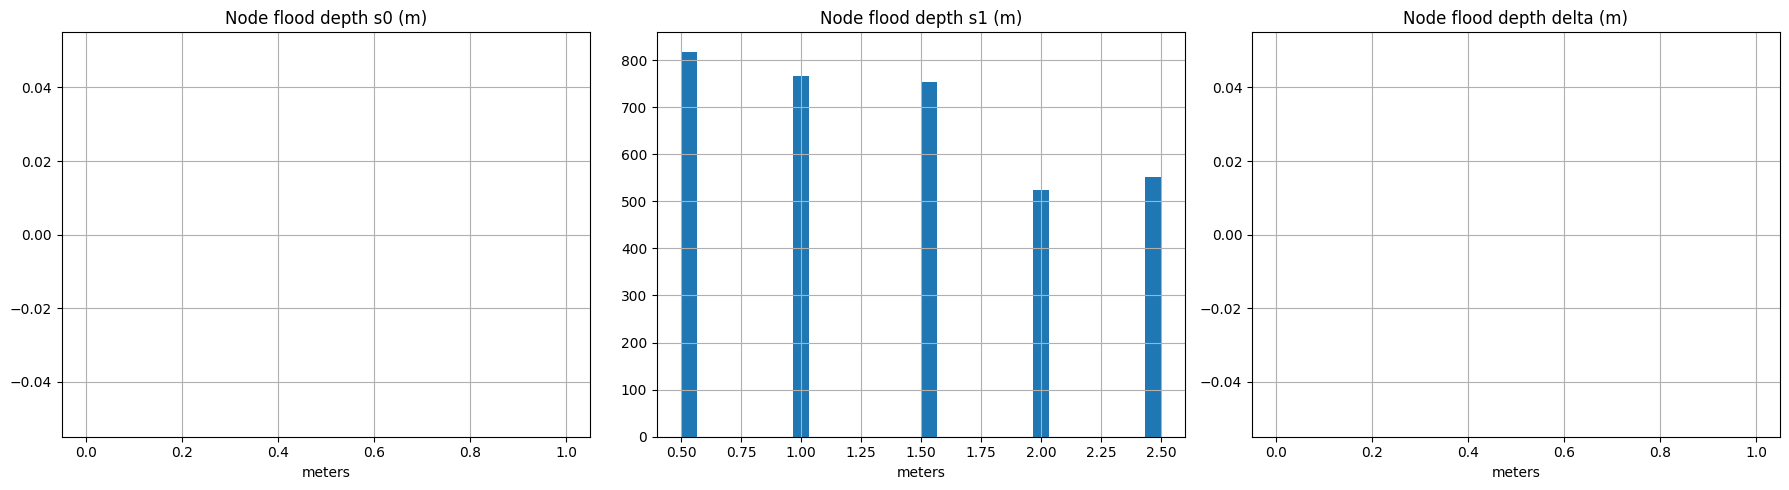

In [ ]:
# Quick visuals: flood levels, deltas, and map
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
level_to_depth = {1: 0.5, 2: 1.0, 3: 1.5, 4: 2.0, 5: 2.5}
depth_t1 = nodes_with_flood["flood_level_s0"].map(level_to_depth)
depth_t2 = nodes_with_flood["flood_level_s1"].map(level_to_depth)
delta_depth = depth_t2 - depth_t1

depth_t1.hist(ax=axes[0], bins=30)
axes[0].set_title("Node flood depth s0 (m)")
depth_t2.hist(ax=axes[1], bins=30)
axes[1].set_title("Node flood depth s1 (m)")
delta_depth.hist(ax=axes[2], bins=30)
axes[2].set_title("Node flood depth delta (m)")
for ax in axes:
    ax.set_xlabel("meters")
plt.tight_layout()
plt.show()


Convert snapshot flood into continuous time flood levels.

In [11]:
snapshot_labels = [s["label"] for s in snapshots]
snapshot_times = [pd.to_datetime(s["timestamp"]) for s in snapshots]
snapshot_order = np.argsort(snapshot_times)
snapshot_labels = [snapshot_labels[i] for i in snapshot_order]
snapshot_times = [snapshot_times[i] for i in snapshot_order]

# Use snapshot range unless you want to override manually
# t_start = pd.Timestamp("2025-11-24 22:00:00")
# t_end = pd.Timestamp("2025-11-26 18:00:00")
t_start = snapshot_times[0]
t_end = snapshot_times[-1]
freq = "1h"
time_index = pd.date_range(start=t_start, end=t_end, freq=freq)

# Incremental flood update using interpolation across arbitrary snapshots
level_to_depth = {1: 0.5, 2: 1.0, 3: 1.5, 4: 2.0, 5: 2.5}
depth_to_level = {v: k for k, v in level_to_depth.items()}
depths_sorted = np.array(sorted(depth_to_level.keys()))

# Build depth matrix per edge for each snapshot
edge_depth_matrix = []
for lbl in snapshot_labels:
    edge_depth_matrix.append(
        edges_with_flood[f"flood_level_{lbl}"].map(level_to_depth).fillna(depths_sorted.min()).to_numpy()
    )
edge_depth_matrix = np.vstack(edge_depth_matrix).T  # shape: (n_edges, n_snapshots)

snapshot_hours = np.array([(ts - t_start).total_seconds() / 3600.0 for ts in snapshot_times])

# Build all interpolated flood columns in parallel (threads) to reduce wall-clock
time_hours = np.array([(ts - t_start).total_seconds() / 3600.0 for ts in time_index], dtype=float)


def interpolate_edge_depth(row):
    depth_series = np.interp(time_hours, snapshot_hours, row, left=row[0], right=row[-1])
    idx = np.abs(depth_series[:, None] - depths_sorted).argmin(axis=1)
    return depths_sorted[idx]


depth_matrix_full = Parallel(n_jobs=N_JOBS, prefer="threads")(
    delayed(interpolate_edge_depth)(row) for row in edge_depth_matrix
)
depth_matrix_full = np.vstack(depth_matrix_full)

# Map depth values back to discrete flood levels
depth_to_level_vec = np.vectorize(depth_to_level.get)
level_matrix = depth_to_level_vec(depth_matrix_full)

flood_df = pd.DataFrame(
    level_matrix,
    columns=[f"flood_level_t{i}" for i in range(level_matrix.shape[1])]
)

edges_with_flood = pd.concat(
    [edges_with_flood.reset_index(drop=True), flood_df.reset_index(drop=True)],
    axis=1,
)

edges_with_flood.to_csv(
    "../data/processed/hatyai_edges_with_dynamic_flood.csv",
    index=False
)